In [5]:
from sequenzo import SequenceData, get_turbulence, get_within_sequence_entropy

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [6]:
data = pd.read_csv("./data/data_irlandais.csv")
time_columns = data.columns[data.columns.str.match(r"^[A-Za-z]{3}\.\d{2}$")]
states = ["joblessness", "FE", "training", "school"]

states = sorted(data[time_columns].melt(value_name="state")["state"].unique())
sequence = SequenceData(
    data=data,
    time=list(time_columns),
    states=states,
)


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 712
[>] Number of time points: 72
[>] Min/Max sequence length: 72 / 72
[>] States: ['FE', 'HE', 'employment', 'joblessness', 'school', 'training']
[>] Labels: ['FE', 'HE', 'employment', 'joblessness', 'school', 'training']
[>] Weights: Not provided


[!] One or more missing values were found after calculating the number of distinct subsequences. They have been replaced with a large number of 1e15 to ensure the calculation continues.


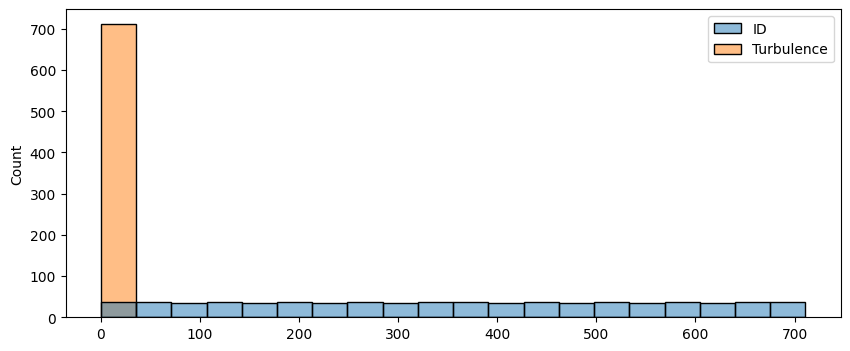

In [7]:
turbulence = get_turbulence(sequence, norm=True)

plt.figure(figsize=(10, 4))
sns.histplot(turbulence, bins=20, color="blue", label="Turbulence")
plt.show()

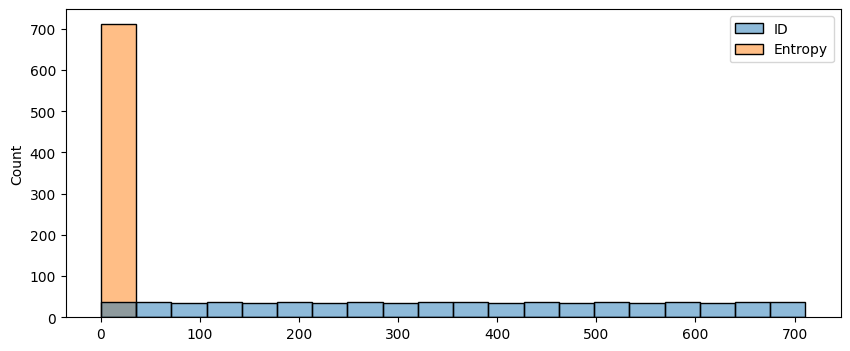

In [8]:
entropy = get_within_sequence_entropy(sequence, norm=True)

plt.figure(figsize=(10, 4))
sns.histplot(entropy, bins=20, color="blue", label="Entropy")
plt.show()